In [1]:
# Data analysis 
# import python libraries

import pandas as pd
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
print("Imports successful!")

Imports successful!


In [14]:
# Create an API call to the NOAA NCEI database
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1'
           '?dataset=daily-summaries'
           '&dataTypes=TOBS'
           '&stations=USC00254432'
           '&startDate=1998-02-01'
           '&endDate=2026-07-15'
           '&units=standard')
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00254432&startDate=1998-02-01&endDate=2026-07-15&units=standard'

In [15]:
# Open and clean the data
kilgore_df = pd.read_csv(
    ncei_url,
    na_values=["-99"],
    index_col="DATE",
    parse_dates=["DATE"]
)
kilgore_df


,STATION,TOBS
DATE,,
1998-02-01,USC00254432,24.0
1998-02-02,USC00254432,24.0
1998-02-03,USC00254432,24.0
1998-02-04,USC00254432,28.0
1998-02-05,USC00254432,27.0
...,...,...
2026-07-11,USC00254432,73.0
2026-07-12,USC00254432,70.0
2026-07-13,USC00254432,71.0


In [16]:
# Keep only the TOBS column
kilgore_df = kilgore_df[["TOBS"]]

# calling method python will only run last method called
kilgore_df.head()
kilgore_df.tail()

,TOBS
DATE,
2026-07-11,73.0
2026-07-12,70.0
2026-07-13,71.0
2026-07-14,70.0
2026-07-15,72.0


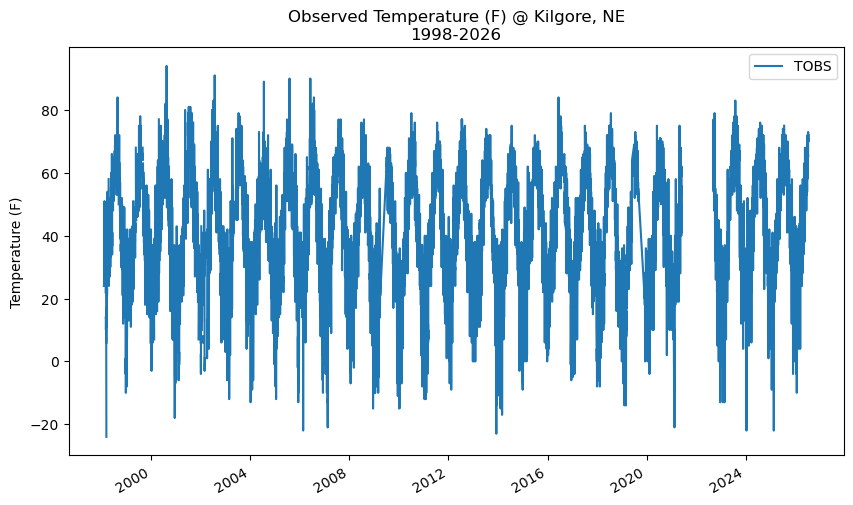

In [17]:
# Plot data with matplotlib
fig, ax = plt.subplots(figsize=(10,6))
kilgore_df.plot(y='TOBS',
                 ax=ax,
                 ylabel='Temperature (F)',
                 xlabel='',
                 title='Observed Temperature (F) @ Kilgore, NE\n1998-2026')
plt.show()

In [18]:
# Take the annual mean of the temperature data, ye equals year end
ann_climate_df = kilgore_df.resample('YE').mean()
ann_climate_df

,TOBS
DATE,
1998-12-31,41.531987
1999-12-31,38.934985
2000-12-31,38.615385
2001-12-31,41.086154
2002-12-31,42.235099
2003-12-31,39.339564
2004-12-31,39.383333
2005-12-31,40.265193
2006-12-31,40.840659


<Axes: xlabel='DATE'>

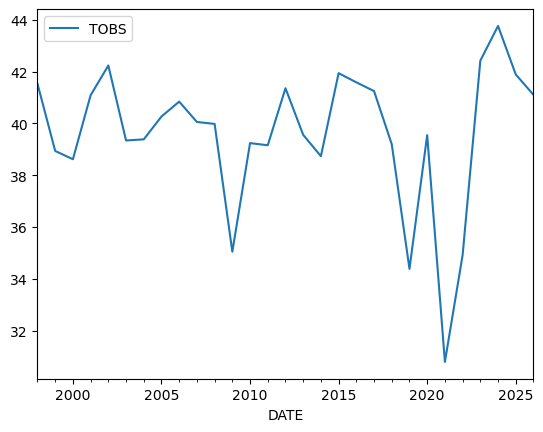

In [19]:
# Plot resampled the data
ann_climate_df.plot()

In [22]:
# Subset the data to look at last 30 years of data, referencing year end means
kilgore_30yr = ann_climate_df.loc["1995":"2025"]
kilgore_30yr

,TOBS
DATE,
1998-12-31,41.531987
1999-12-31,38.934985
2000-12-31,38.615385
2001-12-31,41.086154
2002-12-31,42.235099
2003-12-31,39.339564
2004-12-31,39.383333
2005-12-31,40.265193
2006-12-31,40.840659


<Axes: xlabel='DATE'>

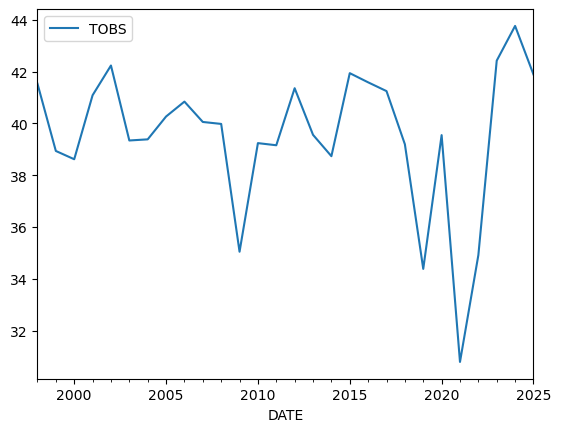

In [23]:
# Plot 30 yrs of data with year end mean
kilgore_30yr.plot()

In [24]:
# Create an interactive plot with hvplot
kilgore_30yr_plot = kilgore_30yr.hvplot()
kilgore_30yr_plot

:Curve   [DATE]   (TOBS)

In [26]:
# Save interactive plot as html to host on the web
hv.save(kilgore_30yr_plot, 'kilgore_plot.html')